# Notebook 1 — Instructor-Led Practical
## Predicting hourly bike demand with machine learning

**Teaching version:** this notebook is fully worked and is meant to be projected, explained, and run live.

### Central question
Can we predict how many bicycles will be rented in a given hour using weather, calendar, and seasonal information?

### What this notebook teaches
- how to frame a regression problem,
- how to detect leakage,
- how to inspect and visualize data,
- how to build preprocessing pipelines,
- how to compare simple and more sophisticated models,
- how to evaluate regression models,
- how to tune hyperparameters using cross-validation,
- how to interpret a fitted model with permutation importance.

### Models used
1. Mean baseline
2. Linear regression
3. Random forest regression
4. Histogram Gradient Boosting Regression — a stronger non-linear ensemble model
5. Tuned Histogram Gradient Boosting model

## Dataset handling

This notebook uses the **UCI Bike Sharing Dataset**, hourly version.

The notebook:
- first checks whether `data/hour.csv` already exists,
- if not, it downloads and extracts the dataset,
- then it loads the CSV into a DataFrame.

For a workshop with unreliable internet, place `hour.csv` in:

```text
data/hour.csv
```

before the session begins.

In [4]:
%pip install -q numpy pandas matplotlib scikit-learn ipython

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 0. Setup

In [5]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import io
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [6]:
def load_csv_from_uci_zip(url, suffix, local_path, sep=","):
    """Load a CSV from a local file if present; otherwise download and cache it."""
    local_path = Path(local_path)
    local_path.parent.mkdir(parents=True, exist_ok=True)

    if local_path.exists():
        print(f"Loading cached dataset from: {local_path}")
        return pd.read_csv(local_path, sep=sep)

    print("Local file not found. Downloading dataset...")
    with urllib.request.urlopen(url) as response:
        raw_zip = response.read()

    with zipfile.ZipFile(io.BytesIO(raw_zip)) as zf:
        matching_files = [name for name in zf.namelist() if name.endswith(suffix)]
        if not matching_files:
            raise FileNotFoundError(f"Could not find {suffix} inside the downloaded ZIP file.")

        selected_file = matching_files[0]
        with zf.open(selected_file) as src:
            content = src.read()

    local_path.write_bytes(content)
    print(f"Saved dataset to: {local_path}")
    return pd.read_csv(local_path, sep=sep)


def make_one_hot_encoder(dense=False):
    """Create a OneHotEncoder compatible with older and newer scikit-learn versions."""
    if dense:
        try:
            return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        except TypeError:
            return OneHotEncoder(handle_unknown="ignore", sparse=False)

    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def evaluate_regression(name, y_true, y_pred):
    """Return a one-row DataFrame with common regression metrics."""
    return pd.DataFrame([{
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R²": r2_score(y_true, y_pred)
    }])


def plot_actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(7, 5))
    plt.scatter(y_true, y_pred, alpha=0.35)
    lower = min(np.min(y_true), np.min(y_pred))
    upper = max(np.max(y_true), np.max(y_pred))
    plt.plot([lower, upper], [lower, upper], linestyle="--")
    plt.xlabel("Actual rentals")
    plt.ylabel("Predicted rentals")
    plt.title(title)
    plt.show()


def plot_residuals(y_true, y_pred, title):
    residuals = y_true - y_pred
    plt.figure(figsize=(7, 5))
    plt.scatter(y_pred, residuals, alpha=0.35)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted rentals")
    plt.ylabel("Residual = actual - predicted")
    plt.title(title)
    plt.show()

## 1. Load the dataset

The target variable is hourly rental demand.

The data contains:
- calendar information,
- weather conditions,
- normalized continuous weather variables,
- rental counts.

In [7]:
BIKE_URL = "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip"

bike = load_csv_from_uci_zip(
    BIKE_URL,
    suffix="hour.csv",
    local_path="data/hour.csv",
    sep=","
)

bike.head()

Local file not found. Downloading dataset...
Saved dataset to: data\hour.csv


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## 2. Basic dataset inspection

In [10]:
print("Shape:", bike.shape)
print("\nColumns:")
print(list(bike.columns))
display(bike.head())
display(bike.describe(include="all").T)

Shape: (17379, 17)

Columns:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
instant,17379.0,NaN,NaN,NaN,8690.0,5017.0295,1.0,4345.5,8690.0,13034.5,17379.0
dteday,17379,731,2011-01-01,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,17379.0,NaN,NaN,NaN,2.50164,1.106918,1.0,2.0,3.0,3.0,4.0
yr,17379.0,NaN,NaN,NaN,0.502561,0.500008,0.0,0.0,1.0,1.0,1.0
mnth,17379.0,NaN,NaN,NaN,6.537775,3.438776,1.0,4.0,7.0,10.0,12.0
hr,17379.0,NaN,NaN,NaN,11.546752,6.914405,0.0,6.0,12.0,18.0,23.0
holiday,17379.0,NaN,NaN,NaN,0.02877,0.167165,0.0,0.0,0.0,0.0,1.0
weekday,17379.0,NaN,NaN,NaN,3.003683,2.005771,0.0,1.0,3.0,5.0,6.0
workingday,17379.0,NaN,NaN,NaN,0.682721,0.465431,0.0,0.0,1.0,1.0,1.0
weathersit,17379.0,NaN,NaN,NaN,1.425283,0.639357,1.0,1.0,1.0,2.0,4.0


### Teaching note
Before modeling, learners should know:
- how many rows and columns exist,
- which column is the target,
- which features are numeric or categorical,
- whether any columns are suspiciously close to the target.

## 3. Check missing values and duplicates

In [11]:
missing_summary = bike.isna().sum().sort_values(ascending=False)
duplicate_count = bike.duplicated().sum()

print("Missing values per column:")
display(missing_summary)

print(f"Duplicate rows: {duplicate_count}")

Missing values per column:


instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Duplicate rows: 0


The dataset is relatively clean, which is useful pedagogically.  
We will still use imputation inside our preprocessing pipeline because:
1. it is good practice,
2. real datasets are often less tidy,
3. pipelines should be robust to missing values.

## 4. Frame the machine learning problem

In [12]:
target = "cnt"

print("Target variable:", target)
print("Target description: total hourly bicycle rentals")
display(bike[[target]].describe())

Target variable: cnt
Target description: total hourly bicycle rentals


,cnt
count,17379.000000
mean,189.463088
std,181.387599
min,1.000000
25%,40.000000
50%,142.000000
75%,281.000000
max,977.000000


### Why this is a regression problem
The target `cnt` is a **continuous numeric quantity**:
- 0 rentals,
- 25 rentals,
- 180 rentals,
- 500+ rentals.

Therefore, this is a **supervised regression** task.

## 5. Spot target leakage

In [13]:
bike[["casual", "registered", "cnt"]].head()

,casual,registered,cnt
0,3,13,16
1,8,32,40
2,5,27,32
3,3,10,13
4,0,1,1


The column `cnt` is defined as:

\[
cnt = casual + registered
\]

If we leave `casual` and `registered` in the feature matrix while trying to predict `cnt`, the model would receive the answer indirectly.

That is **data leakage**.

We remove:
- `cnt` because it is the target,
- `casual` and `registered` because they leak the target,
- `instant` because it is only a row identifier.

In [14]:
drop_columns = ["cnt", "casual", "registered", "instant"]

X = bike.drop(columns=drop_columns)
y = bike[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Columns retained:")
print(list(X.columns))

Feature matrix shape: (17379, 13)
Target shape: (17379,)
Columns retained:
['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']


## 6. Explore the target distribution

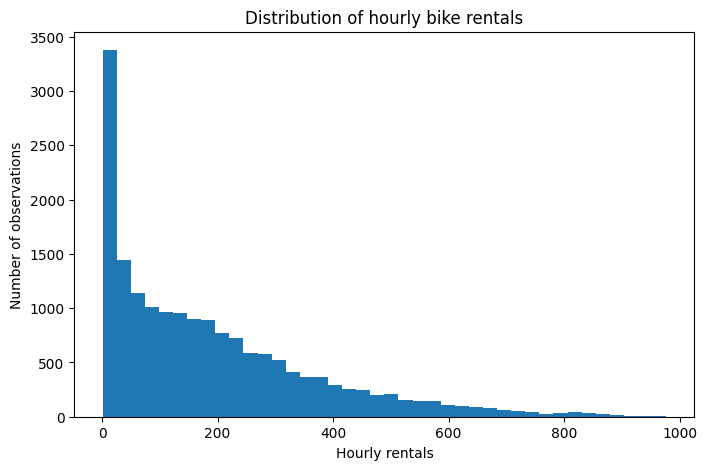

Target summary:


count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(y, bins=40)
plt.xlabel("Hourly rentals")
plt.ylabel("Number of observations")
plt.title("Distribution of hourly bike rentals")
plt.show()

print("Target summary:")
display(y.describe())

### Teaching note
The target is right-skewed:
- many hours have low to moderate rentals,
- fewer hours have very high demand.

This matters because:
- large errors on peak-demand hours may dominate RMSE,
- MAE and RMSE can tell slightly different stories.

## 7. Simple exploratory analysis

In [16]:
eda = bike.copy()
eda["dteday"] = pd.to_datetime(eda["dteday"])

hourly_demand = eda.groupby("hr")["cnt"].mean()
weather_demand = eda.groupby("weathersit")["cnt"].mean()
weekday_demand = eda.groupby("weekday")["cnt"].mean()

display(hourly_demand.rename("average_rentals_by_hour"))
display(weather_demand.rename("average_rentals_by_weather_code"))
display(weekday_demand.rename("average_rentals_by_weekday"))

hr
0      53.898072
1      33.375691
2      22.869930
3      11.727403
4       6.352941
5      19.889819
6      76.044138
7     212.064649
8     359.011004
9     219.309491
10    173.668501
11    208.143054
12    253.315934
13    253.661180
14    240.949246
15    251.233196
16    311.983562
17    461.452055
18    425.510989
19    311.523352
20    226.030220
21    172.314560
22    131.335165
23     87.831044
Name: average_rentals_by_hour, dtype: float64

weathersit
1    204.869272
2    175.165493
3    111.579281
4     74.333333
Name: average_rentals_by_weather_code, dtype: float64

weekday
0    177.468825
1    183.744655
2    191.238891
3    191.130505
4    196.436665
5    196.135907
6    190.209793
Name: average_rentals_by_weekday, dtype: float64

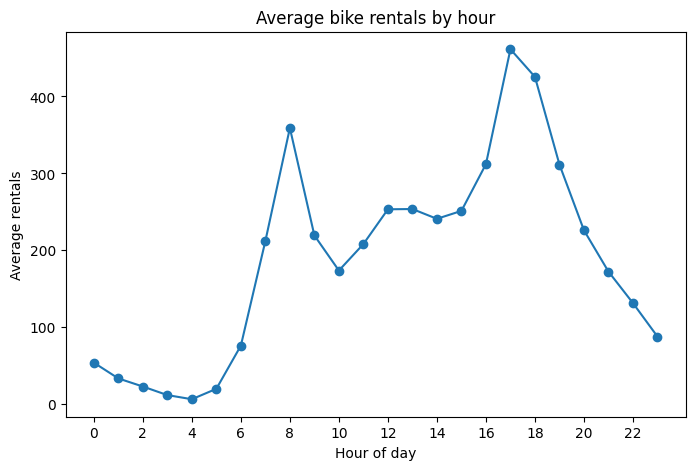

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(hourly_demand.index, hourly_demand.values, marker="o")
plt.xlabel("Hour of day")
plt.ylabel("Average rentals")
plt.title("Average bike rentals by hour")
plt.xticks(range(0, 24, 2))
plt.show()

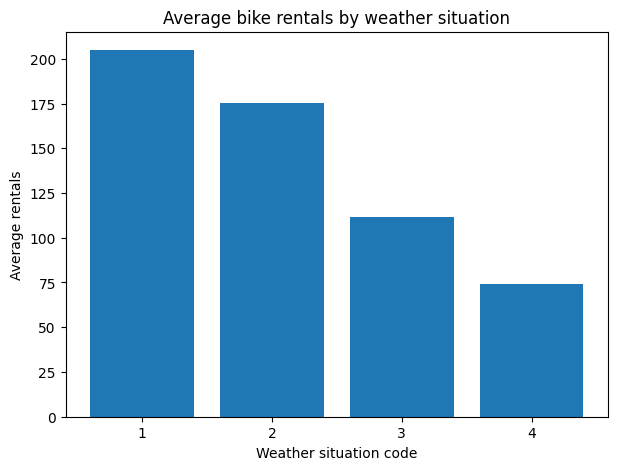

In [18]:
plt.figure(figsize=(7, 5))
plt.bar(weather_demand.index.astype(str), weather_demand.values)
plt.xlabel("Weather situation code")
plt.ylabel("Average rentals")
plt.title("Average bike rentals by weather situation")
plt.show()

### Teaching note
This makes the task more tangible:
- demand tends to vary strongly by **hour of day**,
- poor weather reduces demand,
- demand is not simply linear in one variable.

## 8. Feature engineering

In [19]:
X_model = X.copy()

X_model["dteday"] = pd.to_datetime(X_model["dteday"])
X_model["day_of_month"] = X_model["dteday"].dt.day
X_model["day_of_year"] = X_model["dteday"].dt.dayofyear
X_model = X_model.drop(columns="dteday")

display(X_model.head())
print("Final feature columns:")
print(list(X_model.columns))

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,day_of_month,day_of_year
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,1,1
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,1,1
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,1,1
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,1,1
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1,1


Final feature columns:
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'day_of_month', 'day_of_year']


### Why engineer date features?
Models cannot directly learn from a raw date string.  
We convert the date into numeric calendar signals:
- day of month,
- day of year.

These help the model learn seasonality and gradual changes over the year.

## 9. Define feature groups

In [20]:
categorical_features = [
    "season", "yr", "mnth", "hr",
    "holiday", "weekday", "workingday", "weathersit"
]

numeric_features = [
    col for col in X_model.columns
    if col not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)

Categorical features:
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']

Numeric features:
['temp', 'atemp', 'hum', 'windspeed', 'day_of_month', 'day_of_year']


### Important modeling detail
Several columns are stored as integers but should be treated as **categories**:
- hour,
- weekday,
- month,
- weather code,
- working-day flag.

Treating them as numeric in a linear model would imply artificial ordering and distances.

## 10. Build preprocessing pipelines

In [21]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline_sparse = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", make_one_hot_encoder(dense=False))
])

categorical_pipeline_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", make_one_hot_encoder(dense=True))
])

preprocessor_sparse = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline_sparse, categorical_features)
])

preprocessor_dense = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline_dense, categorical_features)
])

preprocessor_sparse

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### Why two preprocessors?
- Sparse one-hot output is efficient for linear models and random forests.
- Dense output is used for `HistGradientBoostingRegressor`, which expects dense arrays after preprocessing in this setup.

## 11. Split into training and test sets

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training features:", X_train.shape)
print("Test features:", X_test.shape)
print("Training target:", y_train.shape)
print("Test target:", y_test.shape)

Training features: (13903, 14)
Test features: (3476, 14)
Training target: (13903,)
Test target: (3476,)


### Teaching note
The test set is kept untouched until final evaluation.  
Model selection and hyperparameter tuning happen using only the training data.

## 12. Baseline model

In [23]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor_sparse),
    ("model", DummyRegressor(strategy="mean"))
])

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

baseline_results = evaluate_regression(
    "Mean baseline",
    y_test,
    baseline_pred
)

baseline_results

,Model,MAE,RMSE,R²
0,Mean baseline,140.079835,178.034917,-0.00098


### Why the baseline matters
A baseline answers:

> Is our ML model better than a trivial default?

Here, the baseline always predicts the **average training-set demand**.

## 13. Linear regression

In [24]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor_sparse),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

linear_results = evaluate_regression(
    "Linear regression",
    y_test,
    linear_pred
)

linear_results

,Model,MAE,RMSE,R²
0,Linear regression,74.199228,100.333549,0.682088


### Why linear regression?
It is:
- simple,
- interpretable,
- a useful first real model.

But bike rental demand is likely non-linear:
- rush-hour demand,
- weather interactions,
- seasonality.

## 14. Random forest regression

In [25]:
forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor_sparse),
    ("model", RandomForestRegressor(
        n_estimators=180,
        max_depth=None,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

forest_model.fit(X_train, y_train)
forest_pred = forest_model.predict(X_test)

forest_results = evaluate_regression(
    "Random forest",
    y_test,
    forest_pred
)

forest_results

,Model,MAE,RMSE,R²
0,Random forest,29.271191,46.953631,0.930377


### Why a random forest?
Random forests can capture:
- non-linear patterns,
- feature interactions,
- complex split-based decision rules.

They are often much stronger than a linear model on structured/tabular data.

## 15. More sophisticated model: Histogram Gradient Boosting

In [26]:
hist_gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor_dense),
    ("model", HistGradientBoostingRegressor(
        learning_rate=0.08,
        max_iter=250,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=0.1,
        early_stopping=True,
        random_state=RANDOM_STATE
    ))
])

hist_gb_model.fit(X_train, y_train)
hist_gb_pred = hist_gb_model.predict(X_test)

hist_gb_results = evaluate_regression(
    "HistGradientBoosting",
    y_test,
    hist_gb_pred
)

hist_gb_results

,Model,MAE,RMSE,R²
0,HistGradientBoosting,27.723418,42.066056,0.944117


### Why this is a more sophisticated model
Histogram Gradient Boosting builds an additive ensemble of trees:
- each new tree focuses on reducing errors left by previous trees,
- it can model strong non-linear structure,
- it supports regularization and early stopping,
- it is often a strong choice for tabular regression.

This makes it a useful step beyond random forests.

## 16. Compare all models

In [27]:
comparison = pd.concat(
    [
        baseline_results,
        linear_results,
        forest_results,
        hist_gb_results
    ],
    ignore_index=True
).sort_values("RMSE")

comparison

,Model,MAE,RMSE,R²
3,HistGradientBoosting,27.723418,42.066056,0.944117
2,Random forest,29.271191,46.953631,0.930377
1,Linear regression,74.199228,100.333549,0.682088
0,Mean baseline,140.079835,178.034917,-0.000980


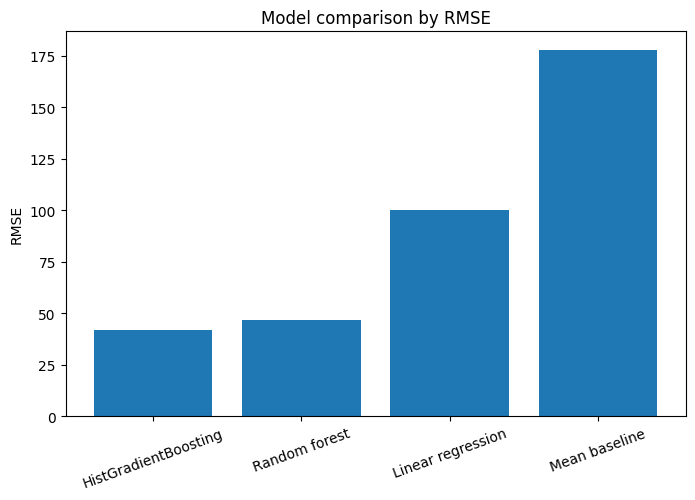

In [28]:
plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["RMSE"])
plt.ylabel("RMSE")
plt.title("Model comparison by RMSE")
plt.xticks(rotation=20)
plt.show()

### Interpreting the metrics
- **MAE**: average absolute error, easy to explain.
- **RMSE**: penalizes larger errors more strongly.
- **R²**: proportion of variance explained compared with a mean-only model.

For operational forecasting, RMSE is useful when large misses are especially costly.

## 17. Diagnose predictions visually

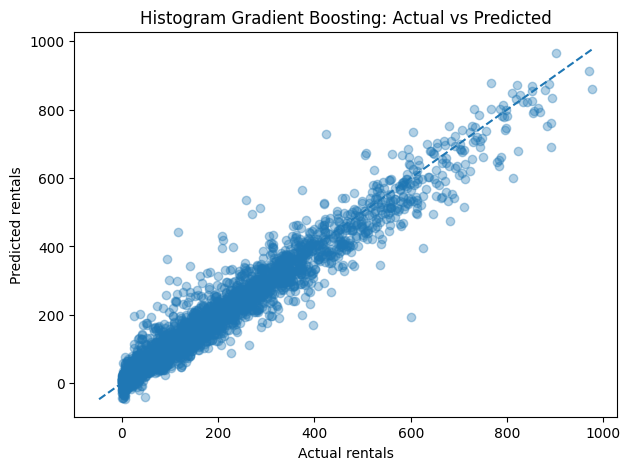

In [29]:
plot_actual_vs_predicted(
    y_test,
    hist_gb_pred,
    "Histogram Gradient Boosting: Actual vs Predicted"
)

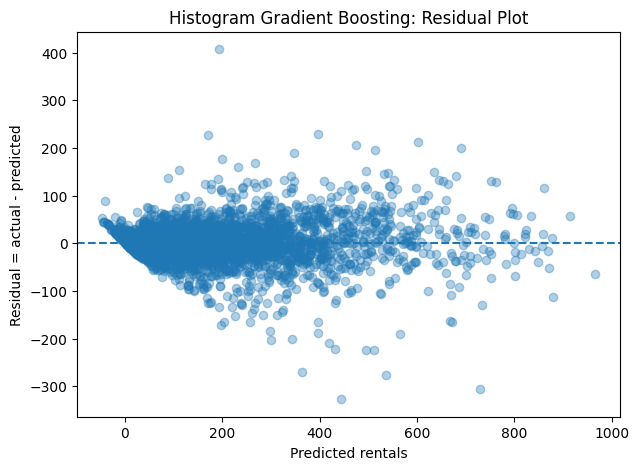

In [30]:
plot_residuals(
    y_test,
    hist_gb_pred,
    "Histogram Gradient Boosting: Residual Plot"
)

### What to look for
- If predictions cluster near the diagonal, the model is doing well.
- Systematic curves or fan shapes in residuals suggest remaining structure or heteroscedasticity.
- Large residuals during peak-demand periods may deserve closer inspection.

## 18. Cross-validation for model stability

In [31]:
cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_scores_hist = cross_validate(
    hist_gb_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=-1,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    "Fold MAE": -cv_scores_hist["test_mae"],
    "Fold RMSE": -cv_scores_hist["test_rmse"],
    "Fold R²": cv_scores_hist["test_r2"]
})

display(cv_summary)
display(cv_summary.agg(["mean", "std"]))

,Fold MAE,Fold RMSE,Fold R²
0,29.104463,43.591627,0.940435
1,29.269749,45.368202,0.939917
2,29.885749,44.947925,0.939559


,Fold MAE,Fold RMSE,Fold R²
mean,29.419987,44.635918,0.939971
std,0.411741,0.928475,0.000440


### Why cross-validation?
A single train/test split can be lucky or unlucky.  
Cross-validation gives a more stable picture of expected model performance.

## 19. Hyperparameter tuning for the advanced model

In [32]:
param_distributions = {
    "model__learning_rate": [0.03, 0.05, 0.08, 0.10],
    "model__max_iter": [150, 250, 350],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__min_samples_leaf": [10, 20, 35],
    "model__l2_regularization": [0.0, 0.05, 0.10, 0.25],
    "model__max_depth": [None, 6, 10]
}

tuning_model = Pipeline(steps=[
    ("preprocessor", preprocessor_dense),
    ("model", HistGradientBoostingRegressor(
        early_stopping=True,
        random_state=RANDOM_STATE
    ))
])

search = RandomizedSearchCV(
    estimator=tuning_model,
    param_distributions=param_distributions,
    n_iter=12,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

search.fit(X_train, y_train)

print("Best CV RMSE:", -search.best_score_)
print("Best parameters:")
display(search.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best CV RMSE: 44.68497769267278
Best parameters:


{'model__min_samples_leaf': 35,
 'model__max_leaf_nodes': 31,
 'model__max_iter': 350,
 'model__max_depth': None,
 'model__learning_rate': 0.1,
 'model__l2_regularization': 0.25}

### Hyperparameter concepts being demonstrated
- `learning_rate`: how much each boosting stage contributes.
- `max_iter`: number of boosting iterations.
- `max_leaf_nodes`: tree complexity.
- `min_samples_leaf`: regularization through minimum leaf size.
- `l2_regularization`: penalty to reduce overfitting.
- `max_depth`: explicit tree depth control.

`RandomizedSearchCV` samples combinations rather than exhaustively trying every possibility.

## 20. Evaluate the tuned advanced model

In [33]:
best_model = search.best_estimator_
tuned_pred = best_model.predict(X_test)

tuned_results = evaluate_regression(
    "Tuned HistGradientBoosting",
    y_test,
    tuned_pred
)

final_comparison = pd.concat(
    [
        comparison,
        tuned_results
    ],
    ignore_index=True
).sort_values("RMSE")

final_comparison

,Model,MAE,RMSE,R²
4,Tuned HistGradientBoosting,26.592573,40.666301,0.947774
0,HistGradientBoosting,27.723418,42.066056,0.944117
1,Random forest,29.271191,46.953631,0.930377
2,Linear regression,74.199228,100.333549,0.682088
3,Mean baseline,140.079835,178.034917,-0.000980


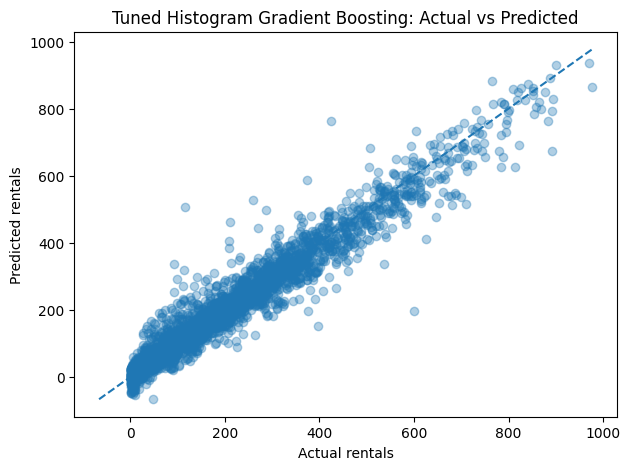

In [34]:
plot_actual_vs_predicted(
    y_test,
    tuned_pred,
    "Tuned Histogram Gradient Boosting: Actual vs Predicted"
)

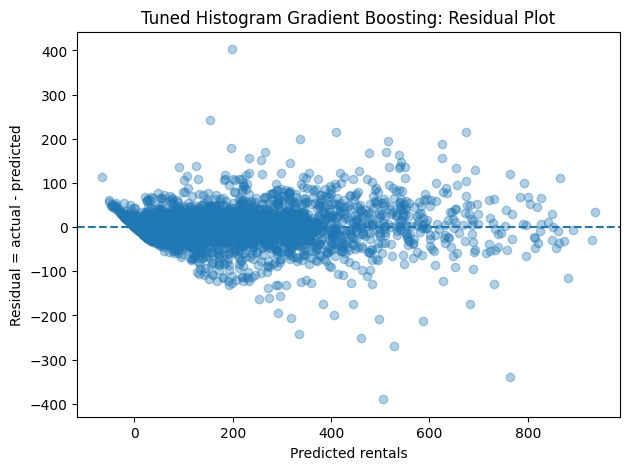

In [35]:
plot_residuals(
    y_test,
    tuned_pred,
    "Tuned Histogram Gradient Boosting: Residual Plot"
)

### Teaching point
Tuning does **not** always produce a dramatic gain.  
That itself is an important lesson:
- sometimes the default model is already good,
- sometimes the search space is weak,
- sometimes the dataset limits performance,
- sometimes feature engineering matters more than tuning.

## 21. Inspect model sensitivity with permutation importance

In [36]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

importance

,feature,importance_mean,importance_std
3,hr,163.564327,2.034930
6,workingday,52.293089,1.384443
1,yr,46.354314,0.371767
8,temp,27.317195,0.419341
10,hum,16.284897,0.403412
13,day_of_year,13.469547,0.560425
5,weekday,8.524564,0.391416
9,atemp,7.545608,0.205349
7,weathersit,7.285128,0.357395
0,season,6.728391,0.531943


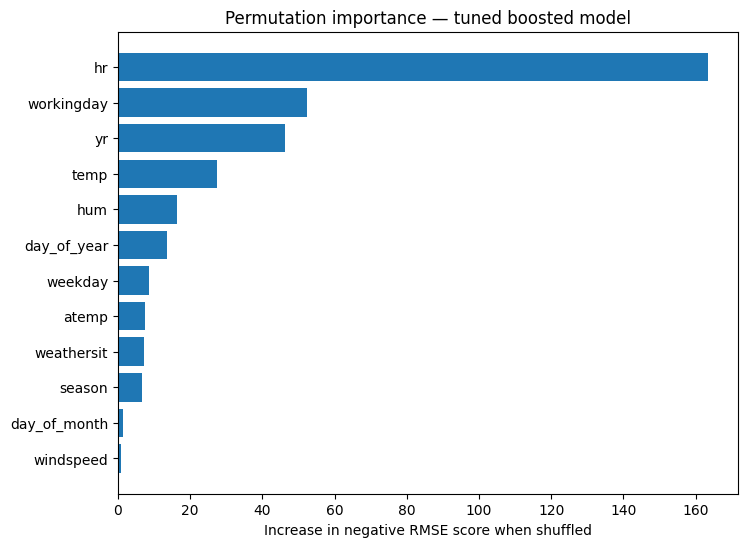

In [37]:
top_importance = importance.head(12).sort_values("importance_mean")

plt.figure(figsize=(8, 6))
plt.barh(top_importance["feature"], top_importance["importance_mean"])
plt.xlabel("Increase in negative RMSE score when shuffled")
plt.title("Permutation importance — tuned boosted model")
plt.show()

### How to explain permutation importance
For each feature:
1. shuffle that feature in the test set,
2. measure how much performance worsens,
3. larger degradation means the model relied more heavily on that feature.

This is useful for more opaque non-linear models.

## 22. Error analysis by hour of day

In [38]:
error_analysis = X_test.copy()
error_analysis["actual"] = y_test.values
error_analysis["predicted"] = tuned_pred
error_analysis["absolute_error"] = np.abs(error_analysis["actual"] - error_analysis["predicted"])

hour_error = (
    error_analysis
    .groupby("hr")["absolute_error"]
    .mean()
    .sort_index()
)

display(hour_error.rename("mean_absolute_error_by_hour"))

hr
0     16.958023
1     15.116433
2     15.284221
3     11.550222
4     12.738378
5     11.529131
6     16.477213
7     32.323312
8     46.592081
9     26.446672
10    23.567710
11    22.659903
12    31.025369
13    27.572080
14    32.750157
15    35.814841
16    33.391556
17    47.676229
18    45.436874
19    35.609060
20    30.261767
21    23.712409
22    22.079068
23    19.964504
Name: mean_absolute_error_by_hour, dtype: float64

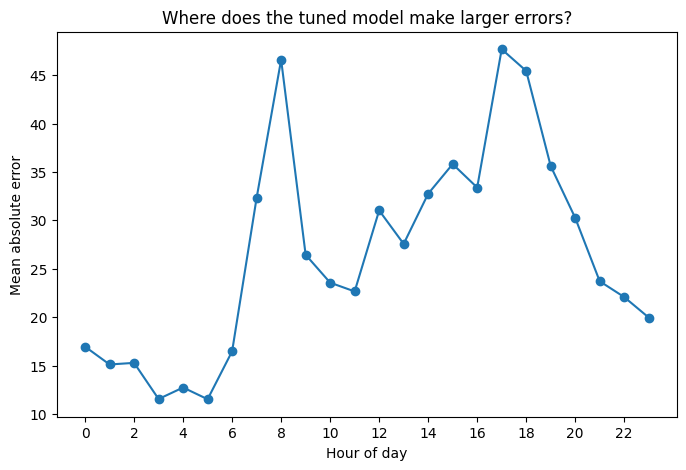

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(hour_error.index, hour_error.values, marker="o")
plt.xlabel("Hour of day")
plt.ylabel("Mean absolute error")
plt.title("Where does the tuned model make larger errors?")
plt.xticks(range(0, 24, 2))
plt.show()

### Teaching note
A global metric can hide local weaknesses.  
Error analysis asks:
- does the model struggle during rush hour?
- does it struggle more at night?
- does it underperform in rare conditions?

## 23. Optional methodological note: random split vs time-aware split

This notebook uses a **random split** because it is simpler for an introductory ML session.

However, bike demand is time-indexed.  
For a real forecasting problem, a chronological split may be more appropriate:

- train on earlier dates,
- test on later dates.

That setup more closely resembles deployment and avoids learning from the future.

In [40]:
# Optional illustration only — not used in the main workflow
time_ordered = bike.copy()
time_ordered["dteday"] = pd.to_datetime(time_ordered["dteday"])
time_ordered = time_ordered.sort_values(["dteday", "hr"])

time_ordered[["dteday", "hr", "cnt"]].head()

,dteday,hr,cnt
0,2011-01-01,0,16
1,2011-01-01,1,40
2,2011-01-01,2,32
3,2011-01-01,3,13
4,2011-01-01,4,1


## 24. Summary

By the end of this notebook, we have:
- framed bike demand prediction as a regression task,
- removed leakage columns,
- engineered features,
- built reusable preprocessing pipelines,
- compared baseline, linear, random forest, and boosted models,
- tuned a sophisticated model using randomized cross-validation,
- evaluated with MAE, RMSE, and R²,
- interpreted model behavior using permutation importance,
- performed targeted error analysis.

This is a complete end-to-end machine learning workflow for tabular regression.

## 25. Suggested live-teaching pauses

Use these pause points during delivery:

1. **After leakage detection**  
   Ask: “What would happen if we kept `casual` and `registered`?”

2. **After linear regression results**  
   Ask: “Why might a linear model struggle here?”

3. **After random forest vs boosting**  
   Ask: “What kinds of patterns can trees capture that a line cannot?”

4. **After tuning**  
   Ask: “Did tuning matter more than model choice?”

5. **After permutation importance**  
   Ask: “Do the important features make domain sense?”